# Neural Trajectories in Attempted Speech

Run alignment-aware trajectory analyses on the durable Willett representation exports created by `notebooks/export_willett_representations.ipynb`. The notebook reads and writes Drive-backed artifacts, so checkpoint extraction does not need to be repeated.

CTC alignment is model-assisted timing. Hidden-state paths describe decoder dynamics; `input_windows` are a closer neural-input control but are still overlapping 280 ms windows at 80 ms cadence.

In [1]:
# Colab / Drive / repository bootstrap.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print(f'Not running in Colab or Drive already unavailable: {exc}')

import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = Path('/content/utah-ssl') if Path('/content').exists() else Path.cwd()
REPO_URL = 'https://github.com/ethan-read/utah-ssl.git'
if str(REPO_DIR).startswith('/content'):
    if not REPO_DIR.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', 'pull', '--ff-only'], cwd=str(REPO_DIR), check=False)
os.chdir(REPO_DIR)
PACKAGE_ROOT = REPO_DIR
os.environ['PYTHONPATH'] = f"{PACKAGE_ROOT}:{os.environ.get('PYTHONPATH', '')}"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

try:
    import sklearn, matplotlib, pandas  # noqa: F401
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'matplotlib', 'scikit-learn'], check=True)
print('REPO_DIR:', REPO_DIR)
print('PACKAGE_ROOT:', PACKAGE_ROOT)

Mounted at /content/drive
REPO_DIR: /content/utah-ssl
PACKAGE_ROOT: /content/utah-ssl


## Configuration

By default this targets the released Stanford GRU export configured in `s11`. Change `EXPORT_NAME` or `MODEL_KEY` to analyze another saved model.

In [2]:
DRIVE_ROOT = Path('/content/drive/MyDrive') if Path('/content/drive/MyDrive').exists() else Path('/Users/home/My Drive')
UTAH_SSL_ROOT = DRIVE_ROOT / 'utah_ssl'
REPRESENTATION_ROOT = UTAH_SSL_ROOT / 'data' / 'representations' / 'willett_manifolds'
OUTPUT_ROOT = UTAH_SSL_ROOT / 'outputs' / 'neural_trajectories'

EXPORT_NAME = "stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1"
MODEL_KEY = "gru"
MODEL_DIR = REPRESENTATION_ROOT / EXPORT_NAME / MODEL_KEY

# Hidden is always present. Input controls require a representation export made with
# SAVE_INPUT_WINDOWS=True. Missing optional controls are skipped cleanly.
REPRESENTATIONS = ('hidden', 'input_windows', 'adapted_input_windows')
MIN_TRIALS = 20
MAX_EVENTS_PER_PHONEME = 100
BEFORE = 3
AFTER = 3
COMPONENTS = 6
PERMUTATIONS = 1000
RELIABILITY_REPETITIONS = 200
SEED = 7

print('MODEL_DIR:', MODEL_DIR)
if not (MODEL_DIR / 'metadata.json').exists():
    available = sorted(str(path.relative_to(REPRESENTATION_ROOT)) for path in REPRESENTATION_ROOT.glob('*/*/metadata.json')) if REPRESENTATION_ROOT.exists() else []
    raise FileNotFoundError(
        f'No representation export found at {MODEL_DIR}. Run the export_willett_representations notebook first '
        f'or change EXPORT_NAME/MODEL_KEY. Available exports: {available}'
    )

MODEL_DIR: /content/drive/MyDrive/utah_ssl/data/representations/willett_manifolds/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru


## Run trajectory analyses

Each representation gets its own durable output folder. Existing outputs are overwritten by a fresh deterministic run.

In [3]:
import json
import numpy as np

shard_manifest = json.loads((MODEL_DIR / 'shards.json').read_text())
with np.load(MODEL_DIR / 'shards' / shard_manifest[0]['shard']) as first_shard:
    available_arrays = set(first_shard.files)
print('Available shard arrays:', sorted(available_arrays))

run_summaries = {}
for representation in REPRESENTATIONS:
    if representation not in available_arrays:
        print(f'\nSkipping {representation}: it was not saved by s11.')
        continue
    output_dir = OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / representation
    command = [
        sys.executable, '-m', 'experiments.manifolds.run_export_analysis',
        str(MODEL_DIR), str(output_dir),
        '--representation', representation,
        '--min-trials', str(MIN_TRIALS),
        '--before', str(BEFORE),
        '--after', str(AFTER),
        '--max-events-per-phoneme', str(MAX_EVENTS_PER_PHONEME),
        '--components', str(COMPONENTS),
        '--permutations', str(PERMUTATIONS),
        '--reliability-repetitions', str(RELIABILITY_REPETITIONS),
        '--seed', str(SEED),
    ]
    print(f'\n=== {representation} ===')
    subprocess.run(command, cwd=str(REPO_DIR), check=True, env=os.environ.copy())
    run_summaries[representation] = json.loads((output_dir / 'summary.json').read_text())

print(json.dumps(run_summaries, indent=2))

Available shard arrays: ['adapted_input_windows', 'hidden', 'input_windows', 'logits', 'patch_end_bin', 'patch_start_bin', 'token_example_index', 'token_index']

=== hidden ===

=== input_windows ===

=== adapted_input_windows ===
{
  "hidden": {
    "model_dir": "/content/drive/MyDrive/utah_ssl/data/representations/willett_manifolds/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru",
    "representation": "hidden",
    "patch_stride_ms": 80,
    "event_count": 18714,
    "retained_event_count": 3807,
    "eligible_event_count": 18714,
    "retained_phoneme_count": 40,
    "pca_explained_variance_ratio": [
      0.22497908771038055,
      0.17082540690898895,
      0.07176695019006729,
      0.05819207429885864,
      0.0504852794110775,
      0.039501868188381195
    ],
    "separation": {
      "within_distance": 5.194784164428711,
      "between_distance": 6.794300079345703,
      "between_minus_within": 1.5995159149169922,
      "permutation_p_value": 0.0009990009

## Display results

The red point marks the CTC-aligned phoneme center. Thin gray lines are individual occurrences and the blue line is their mean path.

,representation,events,phonemes,between_minus_within,permutation_p,PC_variance_sum
0,hidden,3807,40,1.599516,0.000999,0.615751
1,input_windows,3807,40,0.025092,0.087912,0.299112
2,adapted_input_windows,3807,40,0.182904,0.000999,0.223828



hidden: /content/drive/MyDrive/utah_ssl/outputs/neural_trajectories/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru/hidden


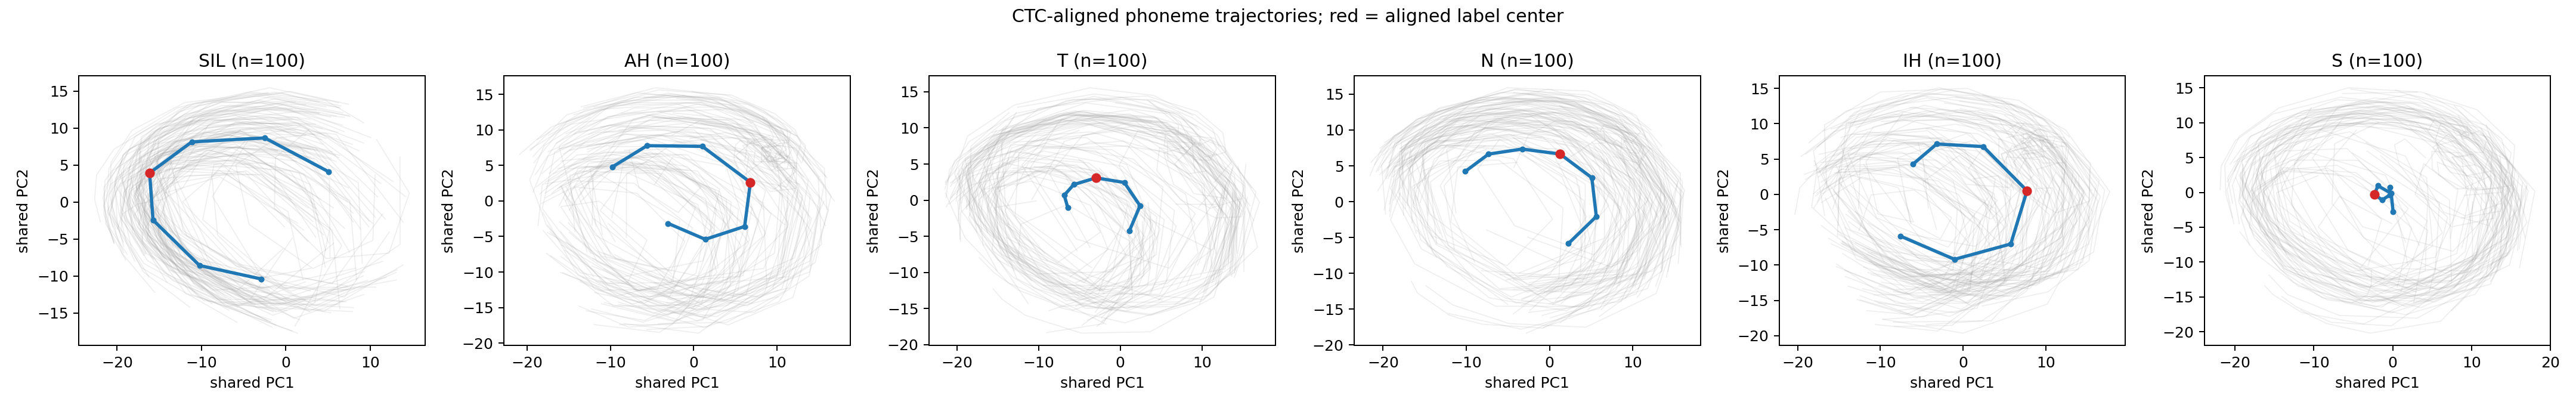

,label_id,symbol,event_count,analyzed_event_count,split_half_reliability
0,2,AE,377,100,0.995848
1,1,AA,287,100,0.995688
2,33,UH,72,72,0.995512
3,6,AY,423,100,0.995369
4,4,AO,221,100,0.995357
5,16,HH,201,100,0.995165
6,34,UW,376,100,0.994743
7,25,OW,253,100,0.994510
8,11,EH,424,100,0.994500
9,13,EY,246,100,0.994129



input_windows: /content/drive/MyDrive/utah_ssl/outputs/neural_trajectories/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru/input_windows


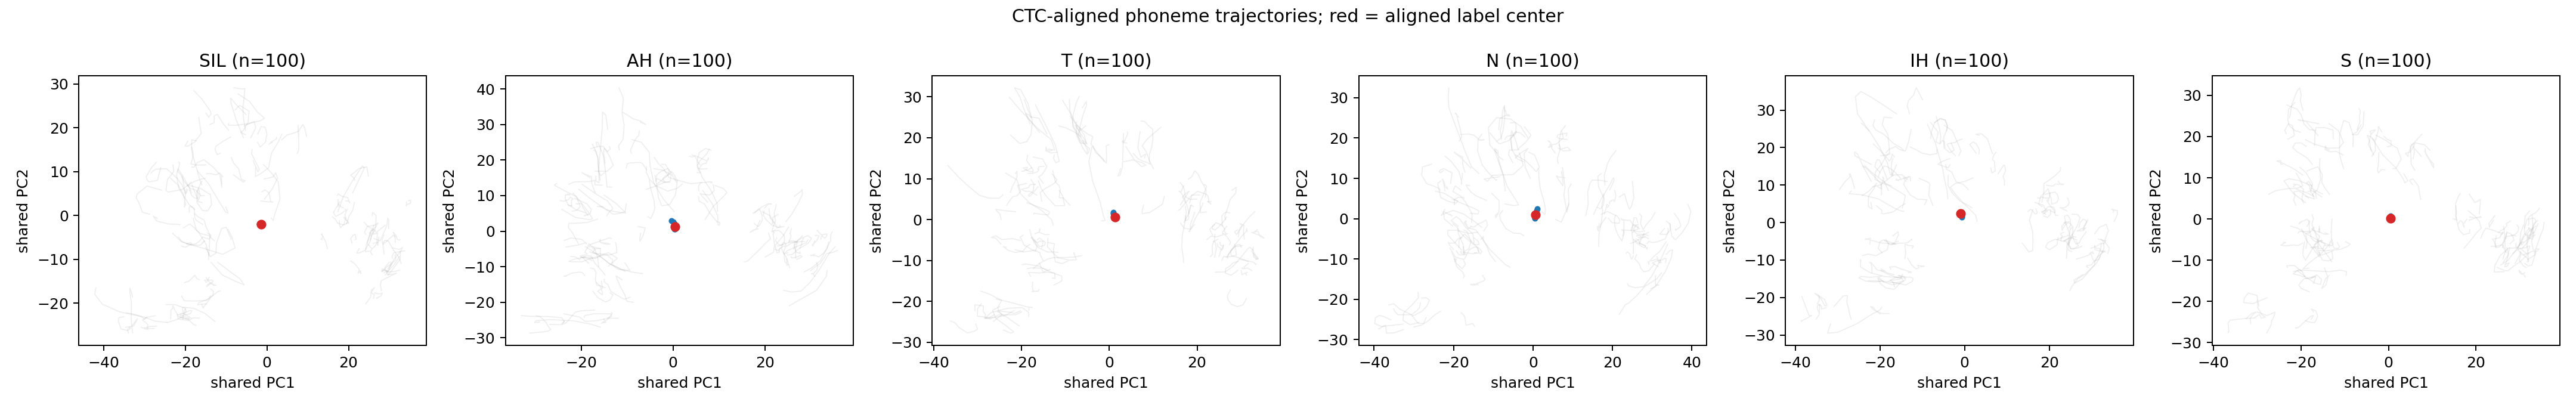

,label_id,symbol,event_count,analyzed_event_count,split_half_reliability
0,5,AW,99,99,0.947759
1,22,M,412,100,0.939341
2,1,AA,287,100,0.926394
3,13,EY,246,100,0.910647
4,32,TH,89,89,0.909492
5,7,B,242,100,0.893081
6,11,EH,424,100,0.885609
7,25,OW,253,100,0.883567
8,2,AE,377,100,0.880302
9,27,P,287,100,0.876995



adapted_input_windows: /content/drive/MyDrive/utah_ssl/outputs/neural_trajectories/stanford_released_gru_s5_val_area6v_soft_phonetic_categories_v1/gru/adapted_input_windows


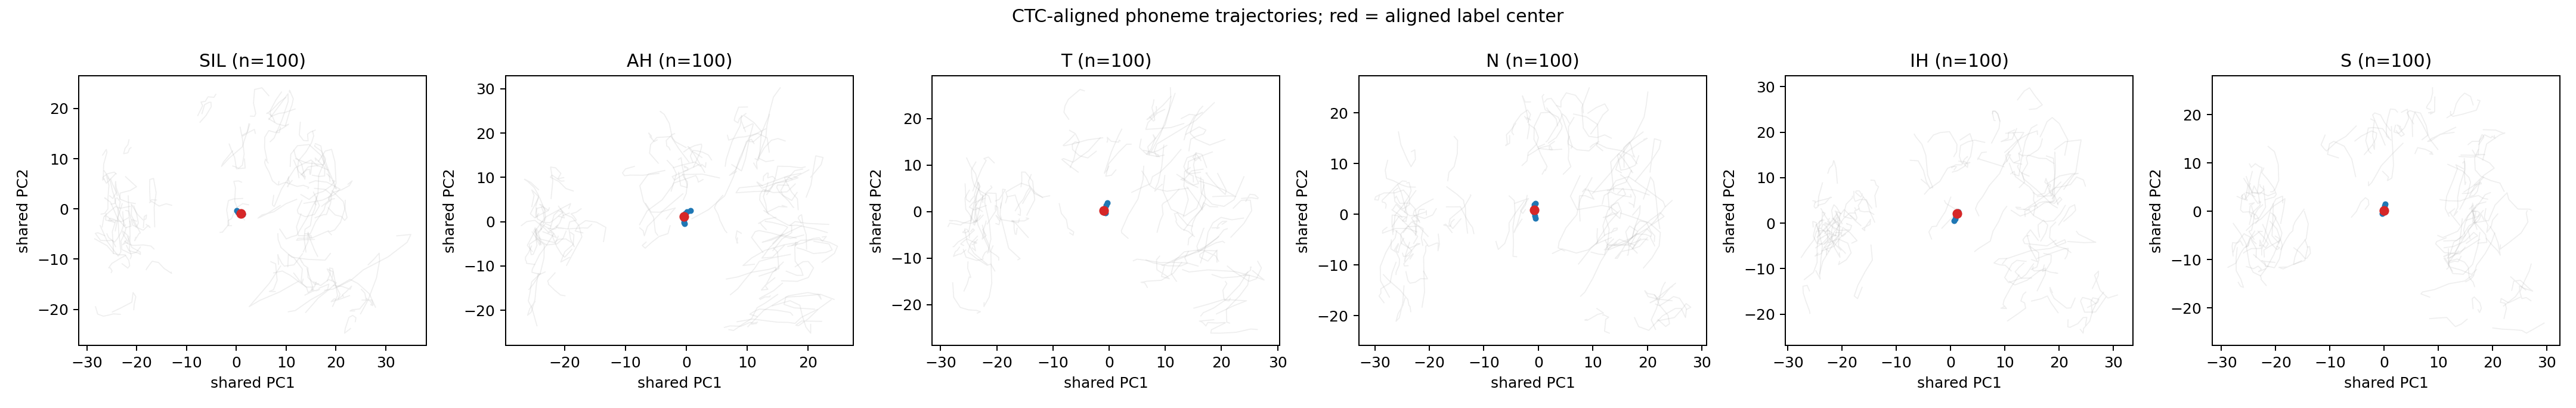

,label_id,symbol,event_count,analyzed_event_count,split_half_reliability
0,13,EY,246,100,0.982941
1,5,AW,99,99,0.980562
2,22,M,412,100,0.978969
3,25,OW,253,100,0.977003
4,11,EH,424,100,0.976409
5,1,AA,287,100,0.973203
6,7,B,242,100,0.972372
7,2,AE,377,100,0.972132
8,15,G,177,100,0.972017
9,27,P,287,100,0.966948


In [4]:
import pandas as pd
from IPython.display import Image, display

summary_rows = []
for representation, summary in run_summaries.items():
    separation = summary['separation']
    summary_rows.append({
        'representation': representation,
        'events': summary['retained_event_count'],
        'phonemes': summary['retained_phoneme_count'],
        'between_minus_within': separation['between_minus_within'],
        'permutation_p': separation['permutation_p_value'],
        'PC_variance_sum': sum(summary['pca_explained_variance_ratio']),
    })
display(pd.DataFrame(summary_rows))

for representation in run_summaries:
    output_dir = OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / representation
    print(f'\n{representation}: {output_dir}')
    display(Image(filename=str(output_dir / 'phoneme_trajectories.png')))
    repeatability = pd.read_csv(output_dir / 'phoneme_repeatability.csv')
    display(repeatability.sort_values('split_half_reliability', ascending=False).reset_index(drop=True))

## Stricter 20 ms held-out-session test

This test reconstructs the normalized 20 ms bins from the saved overlapping input windows, so no checkpoint rerun is needed. It fits preprocessing and PCA only on training sessions, subtracts the training-session grand-mean trajectory, and evaluates held-out sessions. A matched null uses random centers from the same utterances and attaches each real event's phoneme label to its random path.

The reconstruction is exact for bins covered by the exported patches: duplicate observations in overlapping windows are averaged. The final uncovered utterance tail is unavailable because the decoder's floor patching never consumed it.

In [ ]:
import json
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from experiments.manifolds import ctc_forced_align, split_half_reliability, trajectory_separation
from experiments.manifolds.io import load_representation_export

raw_shard_manifest = json.loads((MODEL_DIR / 'shards.json').read_text())
with np.load(MODEL_DIR / 'shards' / raw_shard_manifest[0]['shard']) as raw_first_shard:
    available_arrays = set(raw_first_shard.files)

RAW_BEFORE_BINS = 15       # 300 ms at 20 ms/bin
RAW_AFTER_BINS = 15
HELDOUT_SESSION_FRACTION = 0.25
RAW_MIN_TRAIN_EVENTS = 20
RAW_MIN_TEST_EVENTS = 8
RAW_MAX_TEST_EVENTS_PER_PHONEME = 100
RAW_COMPONENTS = 6

def reconstruct_bins(token_windows, patch_size, patch_stride):
    token_windows = np.asarray(token_windows, dtype=np.float32)
    if token_windows.shape[1] % patch_size:
        raise ValueError('Window dimension is not divisible by patch_size')
    feature_dim = token_windows.shape[1] // patch_size
    patches = token_windows.reshape(len(token_windows), patch_size, feature_dim)
    output_length = (len(patches) - 1) * patch_stride + patch_size
    total = np.zeros((output_length, feature_dim), dtype=np.float32)
    count = np.zeros((output_length, 1), dtype=np.float32)
    for token_index, patch in enumerate(patches):
        start = token_index * patch_stride
        total[start:start + patch_size] += patch
        count[start:start + patch_size] += 1
    if np.any(count == 0):
        raise ValueError('Patch schedule left uncovered bins')
    return total / count

def build_raw_events(model_dir, window_key, seed=7):
    payload = load_representation_export(model_dir, representation=window_key)
    metadata = payload['metadata']
    patch_size = int(metadata['patch_size_bins'])
    patch_stride = int(metadata['patch_stride_bins'])
    blank_index = int(metadata['vocab']['blank_index'])
    examples_by_index = payload['examples'].set_index('example_export_index')
    rng = np.random.default_rng(seed)
    real_events, random_events = [], []
    for example_index, example in examples_by_index.iterrows():
        reference = [int(value) for value in str(example.reference_ids).split()]
        rows = np.flatnonzero(payload['example_indices'] == int(example_index))
        if not len(rows) or not reference:
            continue
        spans = ctc_forced_align(payload['logits'][rows], reference, blank_index=blank_index)
        raw_bins = reconstruct_bins(payload['values'][rows], patch_size, patch_stride)
        low = RAW_BEFORE_BINS
        high = len(raw_bins) - RAW_AFTER_BINS
        if high <= low:
            continue
        for label_id, (onset, offset) in zip(reference, spans):
            token_center = (onset + offset - 1) // 2
            raw_center = token_center * patch_stride + patch_size // 2
            if raw_center < low or raw_center >= high:
                continue
            candidates = np.arange(low, high)
            far_candidates = candidates[np.abs(candidates - raw_center) > RAW_BEFORE_BINS]
            if len(far_candidates) == 0:
                continue
            random_center = int(rng.choice(far_candidates))
            common = {
                'label_id': int(label_id),
                'example_index': int(example_index),
                'session_id': str(example.session_id),
            }
            real_events.append({**common, 'trajectory': raw_bins[raw_center-RAW_BEFORE_BINS:raw_center+RAW_AFTER_BINS+1]})
            random_events.append({**common, 'trajectory': raw_bins[random_center-RAW_BEFORE_BINS:random_center+RAW_AFTER_BINS+1]})
    return real_events, random_events, metadata

def heldout_raw_analysis(model_dir, window_key, seed=7):
    real_events, random_events, metadata = build_raw_events(model_dir, window_key, seed=seed)
    sessions = np.array(sorted({event['session_id'] for event in real_events}), dtype=object)
    rng = np.random.default_rng(seed)
    rng.shuffle(sessions)
    heldout_count = max(1, int(np.ceil(len(sessions) * HELDOUT_SESSION_FRACTION)))
    test_sessions = set(sessions[:heldout_count])
    train_real = [event for event in real_events if event['session_id'] not in test_sessions]
    test_real = [event for event in real_events if event['session_id'] in test_sessions]
    test_random = [event for event in random_events if event['session_id'] in test_sessions]
    train_counts = Counter(event['label_id'] for event in train_real)
    test_counts = Counter(event['label_id'] for event in test_real)
    retained_ids = sorted(label_id for label_id in train_counts if train_counts[label_id] >= RAW_MIN_TRAIN_EVENTS and test_counts[label_id] >= RAW_MIN_TEST_EVENTS)
    train_real = [event for event in train_real if event['label_id'] in retained_ids]
    paired_test = [(real, random) for real, random in zip(test_real, test_random) if real['label_id'] in retained_ids]
    balanced_pairs = []
    for label_id in retained_ids:
        label_pairs = [pair for pair in paired_test if pair[0]['label_id'] == label_id]
        if len(label_pairs) > RAW_MAX_TEST_EVENTS_PER_PHONEME:
            selected = np.sort(rng.choice(len(label_pairs), RAW_MAX_TEST_EVENTS_PER_PHONEME, replace=False))
            label_pairs = [label_pairs[index] for index in selected]
        balanced_pairs.extend(label_pairs)
    if len(retained_ids) < 2 or not balanced_pairs:
        raise RuntimeError('Too few held-out events; reduce RAW_MIN_TEST_EVENTS or held-out fraction')
    grand_mean = np.mean([event['trajectory'] for event in train_real], axis=0)
    train_residual = [event['trajectory'] - grand_mean for event in train_real]
    scaler = StandardScaler().fit(np.concatenate(train_residual, axis=0))
    train_scaled = scaler.transform(np.concatenate(train_residual, axis=0))
    component_count = min(RAW_COMPONENTS, train_scaled.shape[0], train_scaled.shape[1])
    pca = PCA(n_components=component_count, random_state=seed).fit(train_scaled)
    def project(events):
        return [pca.transform(scaler.transform(event['trajectory'] - grand_mean)) for event in events]
    real_test_events = [pair[0] for pair in balanced_pairs]
    random_test_events = [pair[1] for pair in balanced_pairs]
    labels = [event['label_id'] for event in real_test_events]
    real_paths, random_paths = project(real_test_events), project(random_test_events)
    return {
        'window_key': window_key,
        'metadata': metadata,
        'test_sessions': sorted(test_sessions),
        'train_session_count': len(sessions) - heldout_count,
        'test_session_count': heldout_count,
        'labels': labels,
        'real_paths': real_paths,
        'random_paths': random_paths,
        'real_separation': trajectory_separation(real_paths, labels, permutations=PERMUTATIONS, seed=seed),
        'random_separation': trajectory_separation(random_paths, labels, permutations=PERMUTATIONS, seed=seed + 100),
        'real_reliability': split_half_reliability(real_paths, labels, repetitions=RELIABILITY_REPETITIONS, seed=seed),
        'random_reliability': split_half_reliability(random_paths, labels, repetitions=RELIABILITY_REPETITIONS, seed=seed + 100),
        'pca_variance': pca.explained_variance_ratio_,
    }

raw_results = {}
for window_key in ('input_windows', 'adapted_input_windows'):
    if window_key not in available_arrays:
        continue
    print(f'Running held-out 20 ms test: {window_key}')
    raw_results[window_key] = heldout_raw_analysis(MODEL_DIR, window_key, seed=SEED)
print('Finished:', list(raw_results))

In [ ]:
# Summarize and visualize real aligned paths against matched random centers.
import matplotlib.pyplot as plt
from IPython.display import display
raw_vocab = next(iter(raw_results.values()))['metadata']['vocab']
if isinstance(raw_vocab.get('id_to_symbol'), dict):
    id_to_symbol = {int(key): value for key, value in raw_vocab['id_to_symbol'].items()}
else:
    id_to_symbol = {index: value for index, value in enumerate(raw_vocab.get('index_to_symbol', []))}
raw_summary_rows = []
for window_key, result in raw_results.items():
    for center_kind in ('real', 'random'):
        separation = result[f'{center_kind}_separation']
        reliability = result[f'{center_kind}_reliability']
        raw_summary_rows.append({
            'representation': window_key.replace('_windows', '_20ms_bins'),
            'centers': center_kind,
            'heldout_sessions': result['test_session_count'],
            'events': len(result['labels']),
            'phonemes': len(set(result['labels'])),
            'median_split_half': float(np.median(list(reliability.values()))),
            'between_minus_within': separation['between_minus_within'],
            'permutation_p': separation['permutation_p_value'],
        })
raw_summary = pd.DataFrame(raw_summary_rows)
display(raw_summary)

for window_key, result in raw_results.items():
    counts = Counter(result['labels'])
    top_ids = [label_id for label_id, _ in counts.most_common(6)]
    fig, axes = plt.subplots(2, len(top_ids), figsize=(4 * len(top_ids), 7), squeeze=False)
    for row_index, (center_kind, paths) in enumerate((('real', result['real_paths']), ('random', result['random_paths']))):
        for ax, label_id in zip(axes[row_index], top_ids):
            selected = [path for path, path_label in zip(paths, result['labels']) if path_label == label_id]
            for path in selected[:50]:
                ax.plot(path[:, 0], path[:, 1], color='0.7', alpha=0.15, linewidth=0.6)
            mean_path = np.mean(selected, axis=0)
            ax.plot(mean_path[:, 0], mean_path[:, 1], 'o-', color='tab:blue', linewidth=2, markersize=2)
            ax.scatter(mean_path[RAW_BEFORE_BINS, 0], mean_path[RAW_BEFORE_BINS, 1], color='tab:red', s=24, zorder=3)
            ax.set_title(f'{center_kind}: {id_to_symbol.get(label_id, label_id)} (n={len(selected)})')
            ax.set_xlabel('held-out PC1')
            ax.set_ylabel('held-out PC2')
    fig.suptitle(f'{window_key}: 20 ms bins, grand-mean removed; real vs matched random centers')
    fig.tight_layout()
    raw_output_dir = OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / f'{window_key}_20ms_heldout'
    raw_output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(raw_output_dir / 'heldout_real_vs_random.png', dpi=180)
    plt.show()
    pd.DataFrame({
        'label_id': sorted(result['real_reliability']),
        'symbol': [id_to_symbol.get(label_id, str(label_id)) for label_id in sorted(result['real_reliability'])],
        'real_split_half': [result['real_reliability'][label_id] for label_id in sorted(result['real_reliability'])],
        'random_split_half': [result['random_reliability'].get(label_id, np.nan) for label_id in sorted(result['real_reliability'])],
    }).to_csv(raw_output_dir / 'heldout_repeatability.csv', index=False)
raw_summary.to_csv(OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / 'raw_20ms_heldout_summary.csv', index=False)

## Robustness across session splits and trajectory classification

A single five-session split can be unusually easy or difficult. This section repeats the analysis across multiple deterministic session splits and then holds out each session once. It uses training-session phoneme trajectories as nearest-centroid templates and asks whether a trajectory from an unseen analysis session identifies its phoneme or broad articulatory category.

Each standardized path is centered over time before distances and classification, so static condition offsets do not count as trajectory shape. The decoder and its session adapters remain fixed; `held out` refers to fitting the trajectory analysis, not retraining the decoder.

In [ ]:
from experiments.supervised_baselines.representation_export import category_for_symbol

ROBUSTNESS_SPLITS = 25
ROBUSTNESS_MAX_TRAIN_PER_PHONEME = 100
ROBUSTNESS_MAX_TEST_PER_PHONEME = 100
ROBUSTNESS_MAX_PAIRS = 20_000
LOSO_MIN_TEST_EVENTS = 4

def balanced_sample(events, retained_ids, max_per_label, rng):
    sampled = []
    for label_id in retained_ids:
        candidates = [event for event in events if event['label_id'] == label_id]
        if len(candidates) > max_per_label:
            indices = np.sort(rng.choice(len(candidates), max_per_label, replace=False))
            candidates = [candidates[index] for index in indices]
        sampled.extend(candidates)
    return sampled

def path_shape_features(events, grand_mean, scaler):
    paths = []
    for event in events:
        path = scaler.transform(event['trajectory'] - grand_mean)
        path = path - path.mean(axis=0, keepdims=True)
        paths.append(path.astype(np.float32, copy=False))
    return paths

def sampled_distance_effect(paths, labels, rng, max_pairs=ROBUSTNESS_MAX_PAIRS):
    flat = np.stack([path.ravel() for path in paths])
    labels = np.asarray(labels)
    total_pairs = len(flat) * (len(flat) - 1) // 2
    if total_pairs <= max_pairs:
        first, second = np.triu_indices(len(flat), k=1)
    else:
        first = rng.integers(0, len(flat), size=max_pairs)
        second = rng.integers(0, len(flat) - 1, size=max_pairs)
        second = second + (second >= first)
    distances = np.sqrt(np.mean((flat[first] - flat[second]) ** 2, axis=1))
    same = labels[first] == labels[second]
    return float(distances[~same].mean() - distances[same].mean())

def nearest_centroid_accuracy(train_paths, train_labels, test_paths, test_labels):
    label_order = sorted(set(train_labels))
    train_flat = np.stack([path.ravel() for path in train_paths])
    test_flat = np.stack([path.ravel() for path in test_paths])
    train_labels = np.asarray(train_labels, dtype=object)
    centroids = np.stack([train_flat[train_labels == label].mean(axis=0) for label in label_order])
    distances = (test_flat**2).sum(axis=1, keepdims=True) + (centroids**2).sum(axis=1)[None, :] - 2 * test_flat @ centroids.T
    predictions = np.asarray(label_order, dtype=object)[distances.argmin(axis=1)]
    return float(np.mean(predictions == np.asarray(test_labels, dtype=object))), predictions

def evaluate_analysis_split(real_events, random_events, test_sessions, seed, min_test_events=RAW_MIN_TEST_EVENTS):
    rng = np.random.default_rng(seed)
    paired = list(zip(real_events, random_events))
    train_real = [real for real, _ in paired if real['session_id'] not in test_sessions]
    test_pairs = [(real, random) for real, random in paired if real['session_id'] in test_sessions]
    train_counts = Counter(event['label_id'] for event in train_real)
    test_counts = Counter(real['label_id'] for real, _ in test_pairs)
    retained_ids = sorted(label_id for label_id in train_counts if train_counts[label_id] >= RAW_MIN_TRAIN_EVENTS and test_counts[label_id] >= min_test_events)
    if len(retained_ids) < 2:
        return None
    train_real = balanced_sample(train_real, retained_ids, ROBUSTNESS_MAX_TRAIN_PER_PHONEME, rng)
    balanced_pairs = []
    for label_id in retained_ids:
        label_pairs = [pair for pair in test_pairs if pair[0]['label_id'] == label_id]
        if len(label_pairs) > ROBUSTNESS_MAX_TEST_PER_PHONEME:
            indices = np.sort(rng.choice(len(label_pairs), ROBUSTNESS_MAX_TEST_PER_PHONEME, replace=False))
            label_pairs = [label_pairs[index] for index in indices]
        balanced_pairs.extend(label_pairs)
    test_real = [real for real, _ in balanced_pairs]
    test_random = [random for _, random in balanced_pairs]
    grand_mean = np.mean([event['trajectory'] for event in train_real], axis=0)
    scaler = StandardScaler().fit(np.concatenate([event['trajectory'] - grand_mean for event in train_real], axis=0))
    train_paths = path_shape_features(train_real, grand_mean, scaler)
    real_paths = path_shape_features(test_real, grand_mean, scaler)
    random_paths = path_shape_features(test_random, grand_mean, scaler)
    train_labels = [event['label_id'] for event in train_real]
    test_labels = [event['label_id'] for event in test_real]
    real_accuracy, _ = nearest_centroid_accuracy(train_paths, train_labels, real_paths, test_labels)
    random_accuracy, _ = nearest_centroid_accuracy(train_paths, train_labels, random_paths, test_labels)
    train_categories = [category_for_symbol(id_to_symbol.get(label, str(label))) for label in train_labels]
    test_categories = [category_for_symbol(id_to_symbol.get(label, str(label))) for label in test_labels]
    real_category_accuracy, _ = nearest_centroid_accuracy(train_paths, train_categories, real_paths, test_categories)
    random_category_accuracy, _ = nearest_centroid_accuracy(train_paths, train_categories, random_paths, test_categories)
    return {
        'test_sessions': '|'.join(sorted(test_sessions)),
        'test_session_count': len(test_sessions),
        'events': len(test_real),
        'phonemes': len(retained_ids),
        'phoneme_chance': 1.0 / len(retained_ids),
        'category_majority_baseline': max(Counter(test_categories).values()) / len(test_categories),
        'real_separation': sampled_distance_effect(real_paths, test_labels, rng),
        'random_separation': sampled_distance_effect(random_paths, test_labels, rng),
        'real_phoneme_accuracy': real_accuracy,
        'random_phoneme_accuracy': random_accuracy,
        'real_category_accuracy': real_category_accuracy,
        'random_category_accuracy': random_category_accuracy,
    }

robustness_frames = {}
loso_frames = {}
for window_key in ('input_windows', 'adapted_input_windows'):
    if window_key not in available_arrays:
        continue
    print(f'Preparing 20 ms events once for {window_key}...')
    real_events, random_events, _ = build_raw_events(MODEL_DIR, window_key, seed=SEED)
    sessions = np.asarray(sorted({event['session_id'] for event in real_events}), dtype=object)
    split_rows = []
    heldout_count = max(1, int(np.ceil(len(sessions) * HELDOUT_SESSION_FRACTION)))
    for split_index in range(ROBUSTNESS_SPLITS):
        split_rng = np.random.default_rng(SEED + split_index)
        test_sessions = set(split_rng.choice(sessions, heldout_count, replace=False))
        result = evaluate_analysis_split(real_events, random_events, test_sessions, SEED + split_index)
        if result is not None:
            result['split'] = split_index
            split_rows.append(result)
    robustness_frames[window_key] = pd.DataFrame(split_rows)
    loso_rows = []
    for session_index, session_id in enumerate(sessions):
        result = evaluate_analysis_split(real_events, random_events, {str(session_id)}, SEED + 10_000 + session_index, min_test_events=LOSO_MIN_TEST_EVENTS)
        if result is not None:
            result['heldout_session'] = str(session_id)
            loso_rows.append(result)
    loso_frames[window_key] = pd.DataFrame(loso_rows)
    print(f'  completed {len(split_rows)} repeated splits and {len(loso_rows)} leave-one-session-out folds')

In [ ]:
# Summaries and direct real-versus-random robustness plots.
robustness_summary_rows = []
for window_key, frame in robustness_frames.items():
    robustness_summary_rows.append({
        'representation': window_key.replace('_windows', '_20ms_bins'),
        'splits': len(frame),
        'fraction_real_separation_gt_random': float((frame.real_separation > frame.random_separation).mean()),
        'median_real_minus_random_separation': float((frame.real_separation - frame.random_separation).median()),
        'median_real_phoneme_accuracy': float(frame.real_phoneme_accuracy.median()),
        'median_random_phoneme_accuracy': float(frame.random_phoneme_accuracy.median()),
        'median_phoneme_chance': float(frame.phoneme_chance.median()),
        'median_real_category_accuracy': float(frame.real_category_accuracy.median()),
        'median_random_category_accuracy': float(frame.random_category_accuracy.median()),
        'median_category_majority_baseline': float(frame.category_majority_baseline.median()),
    })
robustness_summary = pd.DataFrame(robustness_summary_rows)
display(robustness_summary)

for window_key, frame in robustness_frames.items():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    comparisons = [
        ('separation', frame.real_separation, frame.random_separation),
        ('phoneme accuracy', frame.real_phoneme_accuracy, frame.random_phoneme_accuracy),
        ('category accuracy', frame.real_category_accuracy, frame.random_category_accuracy),
    ]
    for ax, (title, real_values, random_values) in zip(axes, comparisons):
        ax.boxplot([real_values, random_values], labels=['real', 'random'], showmeans=True)
        for real_value, random_value in zip(real_values, random_values):
            ax.plot([1, 2], [real_value, random_value], color='0.75', alpha=0.45, linewidth=0.6)
        ax.set_title(title)
    fig.suptitle(f'{window_key}: {len(frame)} held-out-session splits')
    fig.tight_layout()
    output_dir = OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / f'{window_key}_20ms_robustness'
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / 'repeated_split_real_vs_random.png', dpi=180)
    plt.show()
    frame.to_csv(output_dir / 'repeated_session_splits.csv', index=False)
    loso_frames[window_key].to_csv(output_dir / 'leave_one_session_out.csv', index=False)
robustness_summary.to_csv(OUTPUT_ROOT / EXPORT_NAME / MODEL_KEY / 'raw_20ms_robustness_summary.csv', index=False)

print('Leave-one-session-out medians:')
for window_key, frame in loso_frames.items():
    display(pd.DataFrame([{
        'representation': window_key,
        'sessions': len(frame),
        'median_real_minus_random_separation': (frame.real_separation - frame.random_separation).median(),
        'median_real_phoneme_accuracy': frame.real_phoneme_accuracy.median(),
        'median_random_phoneme_accuracy': frame.random_phoneme_accuracy.median(),
        'median_real_category_accuracy': frame.real_category_accuracy.median(),
        'median_random_category_accuracy': frame.random_category_accuracy.median(),
    }]))

## Reading the result

A useful hidden-state result requires both positive path-shape separation and reliable individual phonemes. Compare it with `input_windows`: hidden-only structure supports a decoder-representation claim, while matching input-window structure is closer to evidence in the neural measurements. Neither input-window control is truly raw because each point contains an overlapping 280 ms window.

The next strict test is a pre-patching 20 ms raw-bin export, followed by session-stratified and leave-session-out analysis.

In [ ]:
# Optional Colab resource release.
try:
    from google.colab import runtime
    runtime.unassign()
except Exception:
    pass